# Automated Fabric Defect Classification — Dataset Exploration

**Notebook 01** of the fabric defect classification pipeline.

This notebook explores the *Multi-Class Fabric Defect Detection Dataset* before any modeling work begins. The goal is to understand what we're working with: how many images exist, how they're organized, how balanced the classes are, whether any files are missing or corrupted, and what preprocessing decisions (resizing, normalization, augmentation) the raw data will require.

## 1. Import Libraries

**What:** Load the libraries needed for file handling, image I/O, and visualization.

**Why:** `os`/`pathlib` let us walk the dataset's folder structure, `PIL` reads image files and their metadata (size, format), and `matplotlib` visualizes class distributions and sample images.

In [2]:
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

## 2. Load Dataset

**What:** Download the dataset from Kaggle using `kagglehub`.

**Why:** The dataset (~2.1 GB, 9 classes) is too large to store in the GitHub repo, so it's fetched fresh each time the notebook runs, following the project's `data/` policy of not committing raw data.

**Dataset provenance:**

- **Source:** Kaggle — `ziya07/multi-class-fabric-defect-detection-dataset` (version 3)
- **Size:** ~2.1 GB, 3,067 image files across 9 class folders
- **Licence:** _(fill in from the dataset's Kaggle page)_

In [3]:
import kagglehub

path = kagglehub.dataset_download("ziya07/multi-class-fabric-defect-detection-dataset")
print("Dataset downloaded to:", path)

ds2 = os.path.join(path, "Dataset")

100%|██████████| 2.10G/2.10G [00:16<00:00, 136MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ziya07/multi-class-fabric-defect-detection-dataset/versions/3


## 3. Explore Dataset Structure

**What:** List the top-level folders and confirm they correspond to the 9 expected defect classes.

**Why:** Before counting or loading anything, we need to confirm the folder layout matches assumptions (one subfolder per class) — a mismatch here would break every downstream step.

**Observations:** _There are exactly 9 classe_

In [4]:
class_names = sorted(os.listdir(ds2))
print(f"Number of classes: {len(class_names)}\n")
for cls in class_names:
    print(" -", cls)

Number of classes: 9

 - Broken stitch
 - Needle mark
 - Pinched fabric
 - Vertical
 - defect free
 - hole
 - horizontal
 - lines
 - stain


## 4. Count Images per Class

**What:** Count how many images fall into each defect category.

**Why:** Class imbalance is common in real-world defect datasets (defect-free fabric is usually overrepresented). Knowing the distribution now determines whether we'll need class weighting, oversampling, or augmentation during training.

**Observations:** Defect free is the largest class in this dataset,while vertical is the smallest. In general this output shows class imbalance  

In [5]:
class_counts = {
    cls: len(list((Path(ds2) / cls).glob("*")))
    for cls in class_names
}

total = sum(class_counts.values())
print(f"Total images: {total}\n")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:20s} {count:5d}  ({count / total:.1%})")

Total images: 3067

defect free           1666  (54.3%)
stain                  398  (13.0%)
hole                   281  (9.2%)
lines                  157  (5.1%)
horizontal             136  (4.4%)
Broken stitch          112  (3.7%)
Needle mark            108  (3.5%)
Pinched fabric         108  (3.5%)
Vertical               101  (3.3%)


## 5. Plot Class Distribution

**What:** Visualize the per-class image counts as a bar chart.

**Why:** A chart makes imbalance immediately obvious in a way a printed table doesn't — it directly informs whether we need a weighted loss function or stratified train/val/test splits.

**Observations:** _The imbalance is severe and defect free class stands out_

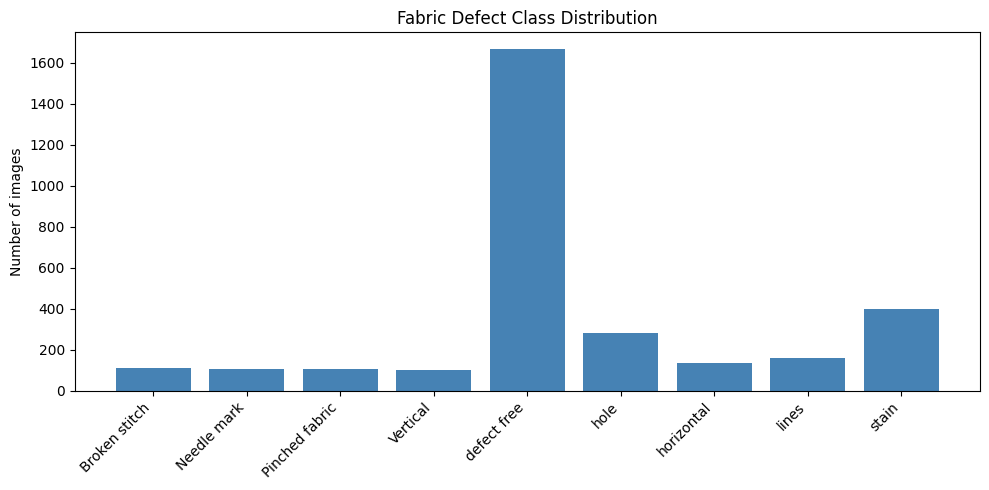

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue")
plt.title("Fabric Defect Class Distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Display Sample Images

**What:** Show one random sample image from each class.

**Why:** Visual inspection builds intuition for how the defects actually look (e.g. how "Hole" differs from "Pinched Fabric" or "Needle Mark") and can surface labeling issues (mislabeled or ambiguous images) before we ever train a model.

**Observations:** Images render inconsistently across classes. "Broken stitch", "Needle mark" and "Pinched fabric" appear as normal fabric photographs, while "Vertical" and "horizontal" show in false colour (purple with yellow streaks), "hole" appears almost black, and "lines" and "stain" have unnatural colour casts.

The purple/yellow appearance is matplotlib's default `viridis` colormap, which it applies automatically to single-channel (grayscale) images. This suggests a colour-mode inconsistency rather than mislabeling — the defect is still visible in "Vertical" as bright streaks. Sections 10–13 investigate this directly.

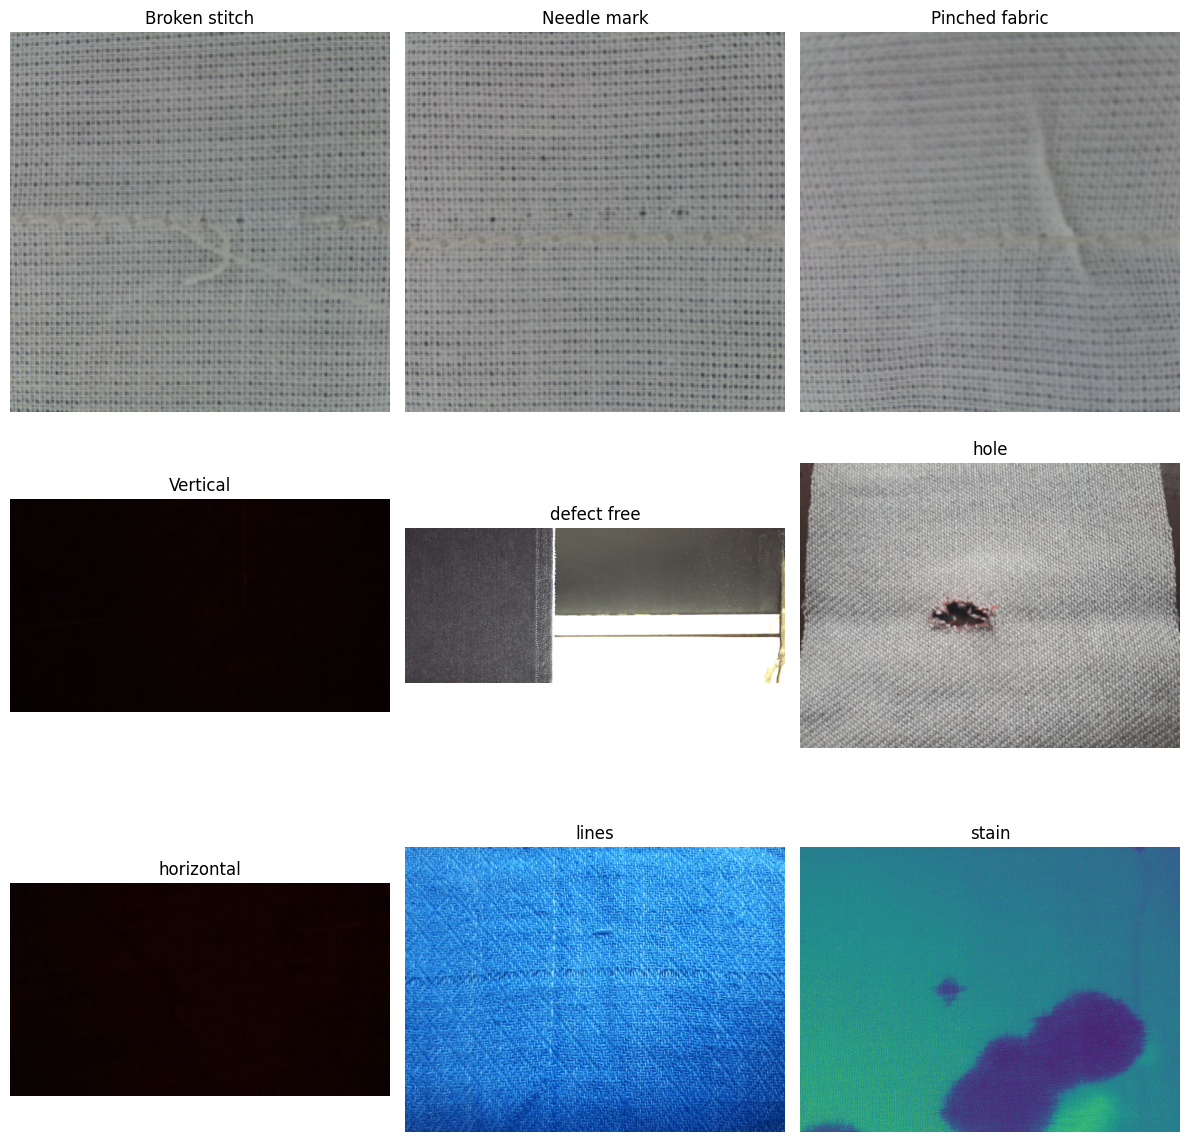

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, cls in zip(axes.flat, class_names):
    img_files = list((Path(ds2) / cls).glob("*"))
    sample_path = random.choice(img_files)
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Check Image Sizes

**What:** Measure the width and height of every image in the dataset.

**Why:** CNNs need a fixed input size. If images vary widely in resolution or aspect ratio, that shapes the resizing/cropping strategy in preprocessing and whether we risk distorting defect shapes.

**Observations:** _Image dimensions vary widely — width ranges from 201 to 4608px, height from 224 to 3456px. Only 13 unique sizes appear across 3067 images, so several images share the same resolution. This variability means all images will need to be resized to a consistent shape before feeding them into a CNN_

In [8]:
sizes = []
for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
        except Exception:
            pass

widths, heights = zip(*sizes)
print(f"Checked {len(sizes)} images")
print(f"Width  - min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)/len(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)/len(heights):.0f}")
print(f"Unique sizes: {len(set(sizes))}")

Checked 3067 images
Width  - min: 201, max: 4608, avg: 1866
Height - min: 224, max: 3456, avg: 891
Unique sizes: 13


## 8. Check File Formats

**What:** Inspect the file extensions and actual image formats (as reported by PIL) present in the dataset.

**Why:** Mixed formats (e.g. JPEG vs PNG vs BMP) can carry different color modes or compression artifacts, which affects how we build the data loader and whether format-specific preprocessing is needed.

**Observations:** _The dataset is almost entirely JPEG (2917 images, ~95%) with a small minority of PNG (150 images, ~5%)_

In [9]:
extensions = Counter()
formats = Counter()

for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        extensions[img_path.suffix.lower()] += 1
        try:
            with Image.open(img_path) as img:
                formats[img.format] += 1
        except Exception:
            pass

print("File extensions:", dict(extensions))
print("PIL-detected formats:", dict(formats))

File extensions: {'.jpg': 2917, '.png': 150}
PIL-detected formats: {'JPEG': 2917, 'PNG': 150}


## 9. Check for Missing or Corrupted Images

**What:** Attempt to open every image file and flag any that fail to load or appear empty/zero-byte.

**Why:** A single corrupted file will crash training mid-epoch if it slips into a DataLoader. Catching this now means we can exclude or re-download bad files before training starts, rather than debugging a crash hours into a run.

**Observations:** _No missing or corrupted images were found (0 zero-byte files, 0 files that failed to open)._

In [10]:
corrupted = []
zero_byte = []

for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        if img_path.stat().st_size == 0:
            zero_byte.append(img_path)
            continue
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupted.append((img_path, str(e)))

print(f"Zero-byte files: {len(zero_byte)}")
print(f"Corrupted files: {len(corrupted)}")

for p in zero_byte:
    print(" [empty]    ", p)
for p, err in corrupted:
    print(" [corrupted]", p, "-", err)

Zero-byte files: 0
Corrupted files: 0


## 10. Inspect Filenames for Grouping Information

**What:** Print the first few filenames in each class folder.

**Why:** Image classification datasets built from production lines often contain multiple photographs of the same physical fabric roll or batch. If images from one roll appear in both the training and test sets, the model can memorise that roll's texture rather than learning the defect — inflating test scores. Filenames are the only available metadata that might reveal such grouping.

**Observations:** No fabric roll or batch identifiers are present, but the filenames reveal two important structures:

1. **Pre-augmented duplicates.** "Vertical", "hole" and "horizontal" contain files like `10.jpg` alongside `10_processed (1).jpg`, `10_processed (2).jpg`, `10_processed (3).jpg` — derived copies sharing one base image.
2. **Multiple naming conventions.** "Broken stitch", "Needle mark" and "Pinched fabric" use a structured `A_NN_NNN` scheme (`A_02_*`, `A_08_*`, `A_03_*`) where the middle field appears to encode defect type; "lines" uses camera timestamps (`20180531_140300.jpg`, `line_2018-09-19 15_19_10.jpg`); "stain" uses plain sequential numbering; "defect free" begins with `0001_000_00.png`.

This indicates the dataset was assembled from several source collections, and that a naive random split would leak augmented copies across the train/test boundary.

## 11. Quantify Duplicate / Pre-Augmented Images

**What:** Strip the `_processed (N)` suffix to recover each image's base identifier, then compare total file count against unique base images per class.

**Why:** The ratio tells us how much of the dataset is genuinely independent data versus derived copies. This determines both the true dataset size and whether a group-aware split is required.

**Observations:** Three classes contain pre-augmented duplicates:

| Class | Files | Unique | Ratio |
|---|---:|---:|---:|
| horizontal | 136 | 34 | 4.00 |
| Vertical | 101 | 32 | 3.16 |
| hole | 281 | 143 | 1.97 |

The other six classes have a 1.00 ratio — no duplication. This reduces the dataset from 3,067 files to **2,758 genuinely distinct images**, and shrinks "Vertical" and "horizontal" to only ~32 and ~34 images respectively. These two classes are far smaller than the raw counts suggested.

## 12. Check Source Heterogeneity Across Classes

**What:** Classify each filename into a naming-pattern bucket and count patterns per class.

**Why:** If the normal class ("defect free") originated from an entirely different collection than the defect classes, a model could achieve high accuracy by detecting source artifacts — camera, lighting, compression — rather than actual defects. This is *shortcut learning*, and it would invalidate the results. The test is whether normal and defective images share any source.

**Observations:** The dataset is confirmed to be a composite of several collections, but crucially **the sources overlap between normal and defective classes**:

- `F_other` — the dominant pattern in "defect free" (1,454 files) — is also the *entire* source of "Broken stitch" (112), "Needle mark" (108) and "Pinched fabric" (108)
- `C_numeric` appears in "defect free" (72) as well as "stain" (398), "horizontal" (34) and "Vertical" (23)

Because normal and defective images coexist within the same collections, the model cannot separate defect from non-defect by source artifact alone. The shortcut-learning risk is therefore materially reduced, though multi-source composition remains a documented limitation.

*Note:* the `F_other` bucket is a catch-all and groups the `A_NN_NNN` files together with other schemes; a finer-grained regex would separate them further.

## 13. Verify Colour Mode of Pre-Augmented Files

**What:** Compare PIL colour modes between original images and their `_processed` derivatives.

**Why:** Section 6 showed several classes rendering in false colour. If the `_processed` files turn out to be single-channel, that fully explains the anomaly — and reveals a second problem: grayscale images existing in only some classes becomes a feature the model can exploit as a shortcut.

**Observations:** **Every** `_processed` file is mode `L` (single-channel grayscale), with no exceptions:

| Class | Processed | Original |
|---|---|---|
| Vertical | 69 × `L` | 23 × `RGB`, 9 × `L` |
| hole | 138 × `L` | 143 × `RGB` |
| horizontal | 102 × `L` | 34 × `RGB` |

This confirms the section 6 anomaly was a colour-mode rendering artifact, **not** mislabeling — the images are correctly labelled but stored as grayscale, which matplotlib displays using its default colormap.

It also exposes a subtler risk: grayscale files exist in only three of the nine classes, so "is this image grayscale?" would act as a direct predictor of those classes. Combined with the fact that these files are derivatives carrying no new information, they will be **excluded** during preprocessing, with augmentation instead applied uniformly across all classes at training time.

## 15. Summary

### Dataset provenance

- **Source:** Kaggle — `ziya07/multi-class-fabric-defect-detection-dataset` (version 3)
- **Download size:** ~2.1 GB
- **Raw file count:** 3,067 across 9 class folders
- **Unique images after deduplication:** 2,758
- **Licence:** _(fill in from the dataset's Kaggle page)_

### Key findings

- **Class structure:** 9 classes = **8 defect types + 1 normal class** ("defect free"). The dataset therefore supports both defect-type classification and defect / no-defect decisions.
- **Class balance:** severely imbalanced, and *worse* after deduplication — "defect free" rises from 54.3% to 60.4%, while "Vertical" and "horizontal" fall to ~1.2% each (32 and 34 images). Imbalance ratio ≈ 52:1.
- **Image dimensions:** highly variable (201–4608 px wide, 224–3456 px tall; 13 unique resolutions).
- **File formats:** 95% JPEG, 5% PNG.
- **Data integrity:** no missing, zero-byte, or corrupted files.
- **Duplicate leakage:** "Vertical", "hole" and "horizontal" contain pre-augmented `_processed` copies (up to 4× per base image) that would leak between train and test under a naive random split.
- **Colour modes:** all `_processed` files are single-channel grayscale, explaining the section 6 rendering anomaly and creating a class-correlated artifact.
- **Multi-source composition:** the dataset combines several collections, but normal and defective images share sources, so defect-vs-normal is not trivially separable by acquisition artifact.

### Baseline

A majority-class classifier achieves **60.4% accuracy** but only **0.084 macro F1**. Accuracy is therefore misleading on this dataset; **macro F1** is adopted as the primary metric, with **per-class recall** reported separately for the rare defect types.

### Implications for preprocessing (Notebook 02)

1. **Exclude all `_processed` files** — they are grayscale derivatives, carry no new information, and act as a class-correlated shortcut.
2. **Convert every image to RGB** to normalise the JPEG/PNG and grayscale/colour inconsistencies.
3. **Resize to 224×224 with letterbox padding** rather than stretching, to preserve the aspect ratio that defines orientation-based defects ("Vertical", "horizontal", "lines").
4. **Use group-aware stratified splitting** on the base image ID so no derivative can cross the train/test boundary.
5. **Use `StratifiedGroupKFold` cross-validation** instead of a single split — with only ~32 images, a 15% test share would give "Vertical" about 5 test images, making per-class recall statistically meaningless.
6. **Apply class weighting** in the loss function, plus augmentation applied uniformly across all classes.

### Limitations

- Two classes ("Vertical", "horizontal") have only ~32–34 unique images, so their per-class metrics will carry wide uncertainty.
- The dataset is a composite of multiple collections; although sources overlap between normal and defective classes, residual source-specific bias cannot be fully ruled out.
- No fabric roll or production batch identifiers exist, so a true batch-level split — the ideal guard against near-duplicate leakage — is not possible. Grouping by base image ID is the closest available approximation.

In [11]:
for cls in class_names:
    files = sorted(p.name for p in (Path(ds2) / cls).glob("*"))
    print(f"\n{cls} ({len(files)} files):")
    for f in files[:8]:
        print("   ", f)


Broken stitch (112 files):
    A_02_001.jpg
    A_02_002.jpg
    A_02_003.jpg
    A_02_004.jpg
    A_02_005.jpg
    A_02_006.jpg
    A_02_007.jpg
    A_02_008.jpg

Needle mark (108 files):
    A_08_001.jpg
    A_08_002.jpg
    A_08_003.jpg
    A_08_004.jpg
    A_08_005.jpg
    A_08_006.jpg
    A_08_007.jpg
    A_08_008.jpg

Pinched fabric (108 files):
    A_03_001.jpg
    A_03_002.jpg
    A_03_003.jpg
    A_03_004.jpg
    A_03_005.jpg
    A_03_006.jpg
    A_03_007.jpg
    A_03_008.jpg

Vertical (101 files):
    1.jpg
    10.jpg
    10_processed (1).jpg
    10_processed (2).jpg
    10_processed (3).jpg
    11.jpg
    11_processed (1).jpg
    11_processed (2).jpg

defect free (1666 files):
    0001_000_00.png
    0001_000_01.png
    0001_000_02.png
    0001_000_03.png
    0001_000_04.png
    0001_000_05.png
    0001_000_06.png
    0002_000_00.png

hole (281 files):
    1.jpg
    10.jpg
    10_processed (1).jpg
    10_processed (2).jpg
    10_processed (3).jpg
    11.jpg
    11_processed

In [13]:
def pattern(name):
    s = Path(name).stem
    if re.match(r'^\d{4}_\d{3}_\d{2}$', s):  return 'A_structured'
    if re.match(r'^\d+_processed', s):        return 'B_processed'
    if re.match(r'^\d+$', s):                 return 'C_numeric'
    if re.match(r'^\d{8}_\d{6}', s):          return 'D_timestamp'
    if s.startswith('line_'):                 return 'E_line_ts'
    return 'F_other'

for cls in class_names:
    c = Counter(pattern(p.name) for p in (Path(ds2) / cls).glob("*"))
    print(f"{cls:20s} {dict(c)}")

Broken stitch        {'F_other': 112}
Needle mark          {'F_other': 108}
Pinched fabric       {'F_other': 108}
Vertical             {'B_processed': 69, 'C_numeric': 23, 'F_other': 9}
defect free          {'F_other': 1454, 'A_structured': 140, 'C_numeric': 72}
hole                 {'B_processed': 138, 'C_numeric': 46, 'F_other': 70, 'E_line_ts': 10, 'D_timestamp': 17}
horizontal           {'B_processed': 102, 'C_numeric': 34}
lines                {'E_line_ts': 152, 'D_timestamp': 5}
stain                {'C_numeric': 398}


## 10. Summary

**Key findings from this exploration:**

- Total images: _3067_
- Number of classes: _9_
- Class balance: _imbalanced_
- Image dimensions: _variable_
- File formats: _mostly JPEG (95%), some PNG (5%)_
- Data quality: _no missing or corrupted files_

**Implications for preprocessing (Notebook 02):** _Resize/crop all images to a fixed size (e.g. 224×224) to match the CNN input requirements
- Convert all images to RGB to normalize PNG/JPEG differences
- Address class imbalance via weighted loss, oversampling minority classes, or targeted augmentation
- Manually review the flagged hole/vertical samples for potential mislabeling before training_